In [45]:
import os
import json
import math
import matplotlib.pyplot as plt
from collections import defaultdict

In [46]:
class Colour:
    BLUE = '\033[94m'
    CYAN = '\033[96m'
    GREEN = '\033[92m'
    YELLOW = '\033[93m'
    RED = '\033[91m'
    BOLD = '\033[1m'
    END = '\033[0m'

In [47]:
def clean_number(value):
    if value is None:
        return 0.0
    
    # if already a numer
    if isinstance(value, (int, float)):
        return float(value)
    else:
        clean_str = str(value).strip()
        is_negative = clean_str.endswith('-') or clean_str.startswith('-')
        
        clean_str = clean_str.replace(',', '.') # french comma -> point
        clean_str = ''.join(c for c in clean_str if c.isdigit() or c == '.' or c == '-')
        
        try:
            val = float(clean_str)
            return val if not is_negative else -abs(val)
        except ValueError:
            return 0.0

In [48]:
def analyze_benford(numbers, input_file, save=True):
    # only positive numbers
    nombres_significatifs = [n for n in numbers if n > 0]
    total_obs = len(nombres_significatifs)

    if total_obs < 5:
        print(f"{Colour.YELLOW}⚠️ Pas assez de données chiffrées pour un test de Benford fiable.{Colour.END}")
        return

    premier_chiffre_count = defaultdict(int)
    for n in nombres_significatifs:
        str_n = str(n).replace('.', '').lstrip('0')
        if str_n:
            premier_chiffre_count[int(str_n[0])] += 1
    
    observed_freqs = []
    expected_freqs = []
    digits = range(1, 10)

    print(f"{Colour.CYAN}analyse Loi de Benford{Colour.END}")
    
    suspicious = False
    for d in digits:
        obs = (premier_chiffre_count[d] / total_obs) * 100
        exp = math.log10(1 + 1/d) * 100
        observed_freqs.append(obs)
        expected_freqs.append(exp)
        
        # suspect if high discrepancy and enough data
        if abs(obs - exp) > 15 and total_obs > 20:
            suspicious = True

    if suspicious:
        print(f"{Colour.RED}🚨 ALERTE : La distribution des chiffres semble anormale (possible falsification).{Colour.END}")
    else:
        print(f"{Colour.GREEN}✅ La distribution des chiffres suit une logique naturelle.{Colour.END}")

    # plot
    plt.figure(figsize=(10, 5))
    bar_width = 0.35
    index = range(len(digits))

    plt.bar(index, observed_freqs, bar_width, label='Observé', color='#3498db', edgecolor='#2980b9', linewidth=1.2)
    plt.bar([i + bar_width for i in index], expected_freqs, bar_width, label='Benford', color='#e74c3c', alpha=0.8, edgecolor='#c0392b', linewidth=1.2)

    plt.xlabel('Premier chiffre (1-9)', fontsize=12, fontweight='bold')
    plt.ylabel('Fréquence (%)', fontsize=12, fontweight='bold')
    plt.title(f"Analyse Loi de Benford - {os.path.basename(input_file)}", fontsize=14, fontweight='bold')
    plt.xticks([i + bar_width / 2 for i in index], digits, fontsize=11)
    plt.yticks(fontsize=10)
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.ylim(0, max(max(observed_freqs), max(expected_freqs)) + 5)
    
    # Ajouter les valeurs au-dessus des barres
    for i, (obs, exp) in enumerate(zip(observed_freqs, expected_freqs)):
        plt.text(i, obs + 0.5, f'{obs:.1f}', ha='center', va='bottom', fontsize=8, color='#2980b9')
        plt.text(i + bar_width, exp + 0.5, f'{exp:.1f}', ha='center', va='bottom', fontsize=8, color='#c0392b')
    
    plt.tight_layout()
    
    os.makedirs("plots", exist_ok=True)
    clean_name = os.path.basename(input_file).replace('.json', '.png')
    if save:
        plt.savefig(f"plots/benford_{clean_name}", dpi=150, bbox_inches='tight')
        print(f"📊 Graphique Benford sauvegardé dans plots/benford_{clean_name}")
    plt.show()
    plt.close()

In [49]:
def verification_bank_statement(input_file, save=True):
    if not os.path.exists(input_file):
        print(f"{Colour.RED}❌ Fichier introuvable : {input_file}{Colour.END}")
        return

    try:
        with open(input_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except json.JSONDecodeError:
        print(f"{Colour.RED}❌ JSON invalide.{Colour.END}")
        return

    print(f"{Colour.BLUE}{Colour.BOLD}" + "="*60)
    print(f" AUDIT RELEVÉ BANCAIRE : {data.get('banque', 'Banque Inconnue')}")
    print(f" Période : {data.get('periode', 'Non spécifiée')}")
    print("="*60 + f"{Colour.END}")

    # extract from json
    solde_debut = clean_number(data.get('solde_debut'))
    solde_fin = clean_number(data.get('solde_fin'))
    devise = data.get('devise', '€')

    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")
    print(f"{Colour.CYAN}analyse des flux{Colour.END}")
    print(f"💰 Solde de départ annoncé : {solde_debut:+.2f} {devise}")

    # transactions analysis
    transactions = data.get('transactions', [])
    cumul_mouvements = 0.0
    nb_transactions = 0
    
    numbers = [abs(solde_debut), abs(solde_fin)]

    errors = []

    for i, t in enumerate(transactions):
        # extract and clean
        libelle = t.get('libelle', 'Opération sans nom')
        montant = clean_number(t.get('montant'))
        
        # if the AI put "null" or 0 on a visible line, it's suspicious
        if montant == 0:
            errors.append(f"Ligne {i+1} ({libelle}) : Montant nul ou non détecté.")
        
        cumul_mouvements += montant
        nb_transactions += 1
        
        if montant != 0:
            numbers.append(abs(montant))

    print(f"📊 Nombre de transactions analysées : {nb_transactions}")
    print(f"∑  Somme des mouvements calculée : {cumul_mouvements:+.2f} {devise}")

    # check equation comptablexs
    solde_theorique = solde_debut + cumul_mouvements
    
    print(f"🏁 Solde final théorique (Départ + Mouvements) : {solde_theorique:+.2f} {devise}")
    print(f"📄 Solde final sur le document : {solde_fin:+.2f} {devise}")

    # check discrepancy
    ecart = abs(solde_theorique - solde_fin)
    
    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")

    if ecart < 0.02:
        print(f"{Colour.GREEN}✅ COHÉRENCE VALIDÉE : Le relevé est mathématiquement juste.{Colour.END}")
    else:
        print(f"{Colour.RED}🚨 ALERTE FRAUDE POSSIBLE : Incohérence comptable.{Colour.END}")
        print(f"   Il y a un trou de {Colour.BOLD}{ecart:.2f} {devise}{Colour.END} inexpliqué.")
        print(f"   Hypothèses :")
        print(f"   1. Une transaction a été effacée ou modifiée (IA ou Photoshop).")
        print(f"   2. Le solde de fin a été modifié manuellement.")
        print(f"   3. L'extraction du PDF a raté une ligne.")

    # other anomalies
    if errors:
        print(f"\n{Colour.RED}⚠️ Anomalies de lignes :{Colour.END}")
        for e in errors:
            print(f"  - {e}")

    # benford
    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")
    analyze_benford(numbers, input_file, save=save)
    print(f"{Colour.YELLOW}" + "-" * 70 + f"{Colour.END}")

 AUDIT RELEVÉ BANCAIRE : Crédit du Nord
 Période : 01/07/2020 au 31/07/2020
----------------------------------------------------------------------
analyse des flux
💰 Solde de départ annoncé : +15878.39 EUR
📊 Nombre de transactions analysées : 43
∑  Somme des mouvements calculée : +1039963.75 EUR
🏁 Solde final théorique (Départ + Mouvements) : +1055842.14 EUR
📄 Solde final sur le document : -306060.82 EUR
----------------------------------------------------------------------
🚨 ALERTE FRAUDE POSSIBLE : Incohérence comptable.
   Il y a un trou de 1361902.96 EUR inexpliqué.
   Hypothèses :
   1. Une transaction a été effacée ou modifiée (IA ou Photoshop).
   2. Le solde de fin a été modifié manuellement.
   3. L'extraction du PDF a raté une ligne.
----------------------------------------------------------------------
analyse Loi de Benford
✅ La distribution des chiffres suit une logique naturelle.


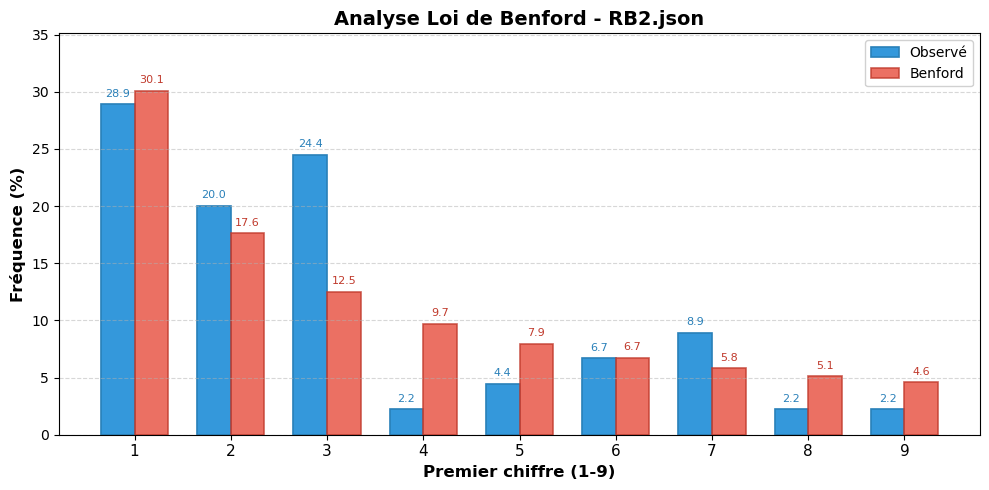

----------------------------------------------------------------------


In [50]:
verification_bank_statement("extracted/RB2.json", save=False)